<a href="https://colab.research.google.com/github/Slamm-alt/2318076_MIslamAlwali_KlasifikasiCitraBuahMetodeKNN/blob/main/2318076MIslamAlwaliKlasifikasiCitraBuahMetodeKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Import Library Yang Diperlukan

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from skimage.feature import graycomatrix, graycoprops

# 3.Mengarahkan Ke Dataset Jeruk

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/DatasetBuah"

categories = ["Apple", "Dragonfruit"]

# 4. Mengecek Apakah Foldernya Sudah Benar

In [26]:
for category in categories:
    print(category, "->", os.path.exists(os.path.join(DATASET_PATH, category)))

Jeruk Sehat -> False
Jeruk Sakit -> False


# 5. Load Data 500 File Citra Yang Sudah Ada Di Google Drive Anda

In [ ]:
data = []
labels = []
file_names = []

for label, category in enumerate(categories):
    folder = os.path.join(DATASET_PATH, category)

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        data.append(img)
        labels.append(label)
        file_names.append(file)

data = np.array(data)
labels = np.array(labels)

print("Total data:", len(data))

Total data: 625


# 6. Visualisasi Perbandingan Data Antara Jeruk Sehat Dan Jeruk Sakit

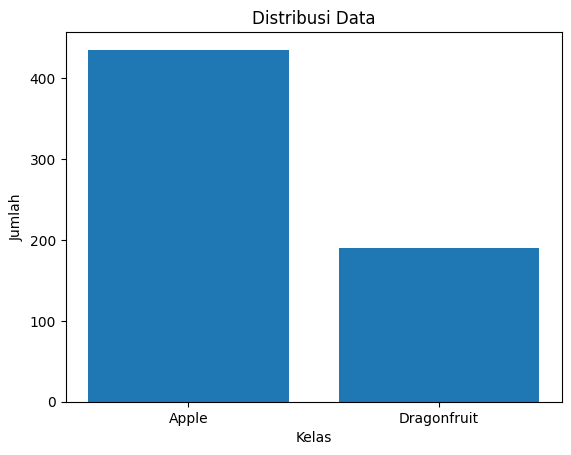

In [ ]:
unique, counts = np.unique(labels, return_counts=True)

plt.figure()
plt.bar(categories, counts)
plt.title("Distribusi Data")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

# 7. Melakukan Ekstraksi Fitur Warna Dan Tekstur

In [ ]:
def extract_features(image):
    # WARNA (HSV)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    color = [
        np.mean(hsv[:,:,0]),
        np.mean(hsv[:,:,1]),
        np.mean(hsv[:,:,2])
    ]

    # TEKSTUR (GLCM)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)

    texture = [
        graycoprops(glcm, 'contrast')[0][0],
        graycoprops(glcm, 'homogeneity')[0][0],
        graycoprops(glcm, 'energy')[0][0],
        graycoprops(glcm, 'correlation')[0][0]
    ]

    return np.hstack([color, texture])

# 8. Memproses Fitur

In [ ]:
features = np.array([extract_features(img) for img in data])
print("Shape fitur:", features.shape)

Shape fitur: (625, 7)


# 9. Pembagian Data Training dan Testing

In [ ]:
X_train, X_test, y_train, y_test, file_train, file_test = train_test_split(
    features, labels, file_names, test_size=0.2, random_state=42
)

# 10. Membuat Model KNN

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 11. Menampilkan Prediksi Dan Akurasi

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.784


# 12. Visualisasi Confusion Matrix

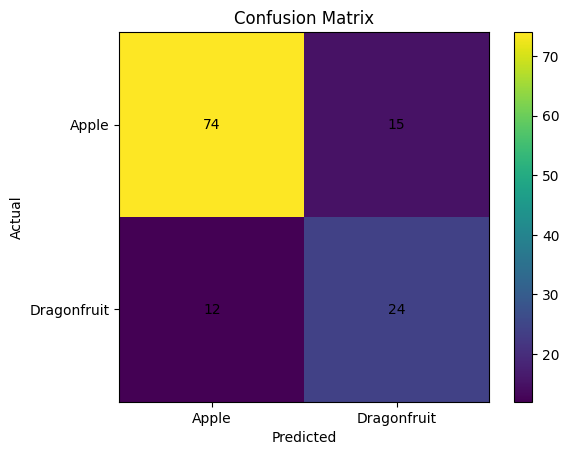

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(2), categories)
plt.yticks(range(2), categories)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

# 13. Kita Lakukan Perbandingan Dengan Nilai K

In [ ]:
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"K = {k}, Akurasi = {accuracy_score(y_test, y_pred)}")

K = 3, Akurasi = 0.784
K = 5, Akurasi = 0.76
K = 7, Akurasi = 0.76


# 14. Grafik Analisis Pengaruh Nilai K terhadap Akurasi

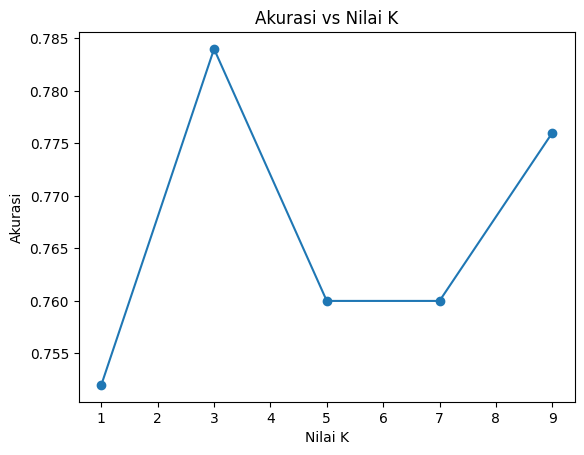

In [ ]:
accuracies = []
k_values = [1,3,5,7,9]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title("Akurasi vs Nilai K")
plt.xlabel("Nilai K")
plt.ylabel("Akurasi")
plt.show()

# 15. Visualisasi Hasil Prediksi Citra

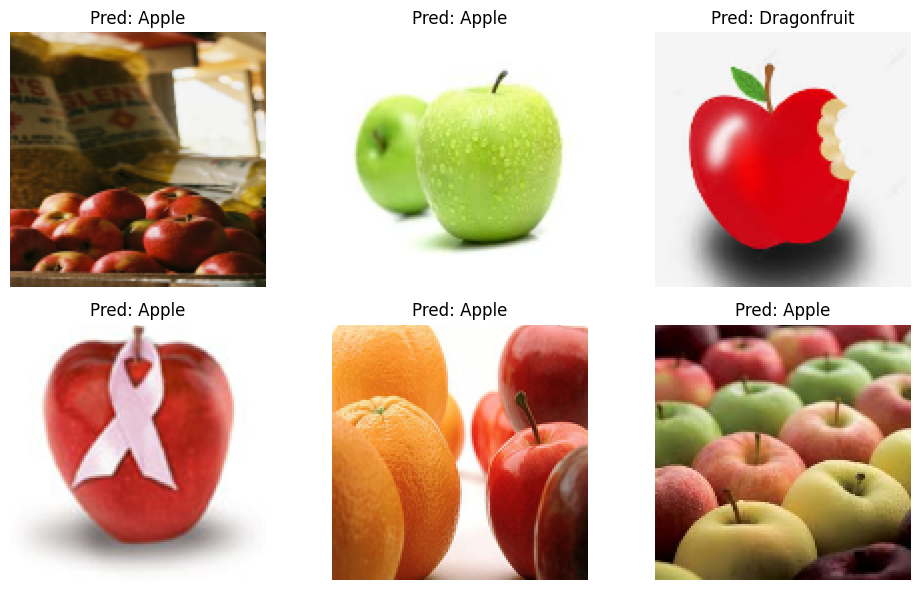

In [ ]:
import random

plt.figure(figsize=(10,6))

# ambil 6 index random dari data test
random_indices = random.sample(range(len(X_test)), 6)

for i, idx in enumerate(random_indices):
    plt.subplot(2,3,i+1)

    # ambil gambar sesuai index test
    img = data[idx]

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {categories[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 16. Penyimpanan Data Fitur dan Hasil Prediksi ke Google Drive

In [ ]:
import os
import pandas as pd

save_path = "/content/drive/MyDrive/Colab Notebooks/Comvis/Uts/Penyakit Buah Jeruk"

os.makedirs(save_path, exist_ok=True)

# Nama fitur
actual_feature_names = [
    "H_mean", "S_mean", "V_mean",
    "Contrast", "Homogeneity",
    "Energy", "Correlation"
]

# Label kategori
categories = ["Jeruk Sehat", "Jeruk Sakit"]

# DATA TESTING
df_features_for_save = pd.DataFrame(
    X_test,
    columns=actual_feature_names
)

# Tambahkan kolom di paling kiri
df_features_for_save.insert(0, 'Nama Gambar', file_test)

# Tambahkan label asli
df_features_for_save['Label Asli'] = [
    categories[label] for label in y_test
]

# Tambahkan hasil prediksi
df_features_for_save['Hasil Prediksi'] = [
    categories[label] for label in y_pred
]

# Tambahkan status
df_features_for_save['Status'] = (
    df_features_for_save['Label Asli']
    == df_features_for_save['Hasil Prediksi']
)

# SIMPAN EXCEL
output_path = os.path.join(save_path, "fitur_dataset.xlsx")

df_features_for_save.to_excel(output_path, index=False)

print("✅ File Excel berhasil disimpan:", output_path)

✅ File Excel berhasil disimpan: /content/drive/MyDrive/Colab Notebooks/Comvis/Uts/Penyakit Buah Jeruk/fitur_dataset.xlsx
